In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/synthetic/healthy_telemetry.csv")

df.head()

,timestamp,temperature,voltage,current,pressure,vibration,rpm,battery
0,2026-01-01 00:00:00,25.248357,27.864301,3.034829,100.405828,0.095281,3002.946184,90.007884
1,2026-01-01 00:00:01,24.935895,27.939843,3.029039,100.684761,0.110316,2998.265267,90.055790
2,2026-01-01 00:00:02,25.333898,27.882409,2.907762,100.826405,0.098395,3028.930748,90.033110
3,2026-01-01 00:00:03,25.776595,28.024911,3.060079,101.048671,0.101471,3046.550465,89.870708
4,2026-01-01 00:00:04,24.903029,28.243206,2.853819,101.312276,0.107928,3021.359437,89.979378


In [2]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (10000, 8)

Columns:
['timestamp', 'temperature', 'voltage', 'current', 'pressure', 'vibration', 'rpm', 'battery']

Missing values:
timestamp      0
temperature    0
voltage        0
current        0
pressure       0
vibration      0
rpm            0
battery        0
dtype: int64


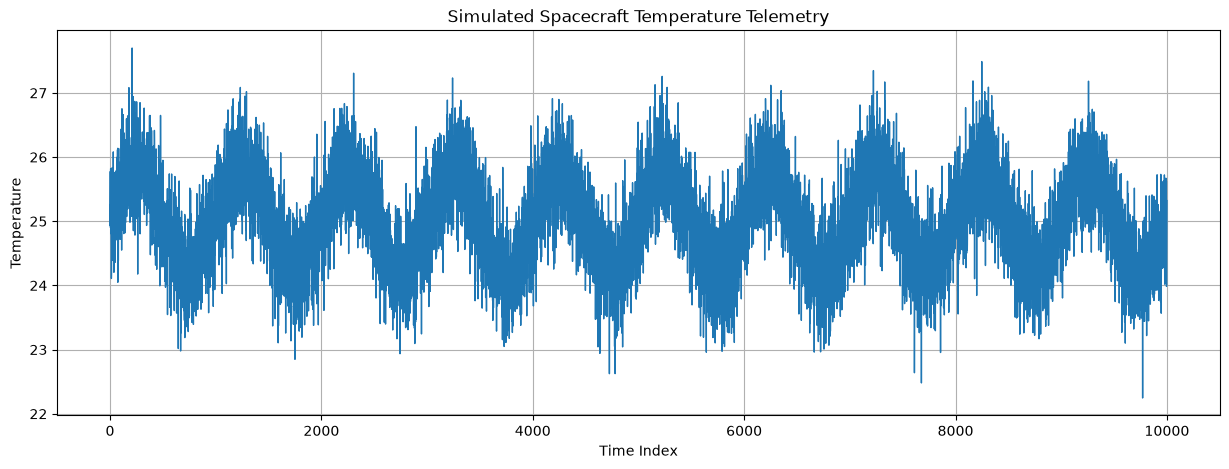

In [3]:
plt.figure(figsize=(15, 5))

plt.plot(
    df["temperature"],
    linewidth=1
)

plt.title("Simulated Spacecraft Temperature Telemetry")
plt.xlabel("Time Index")
plt.ylabel("Temperature")

plt.grid(True)
plt.show()

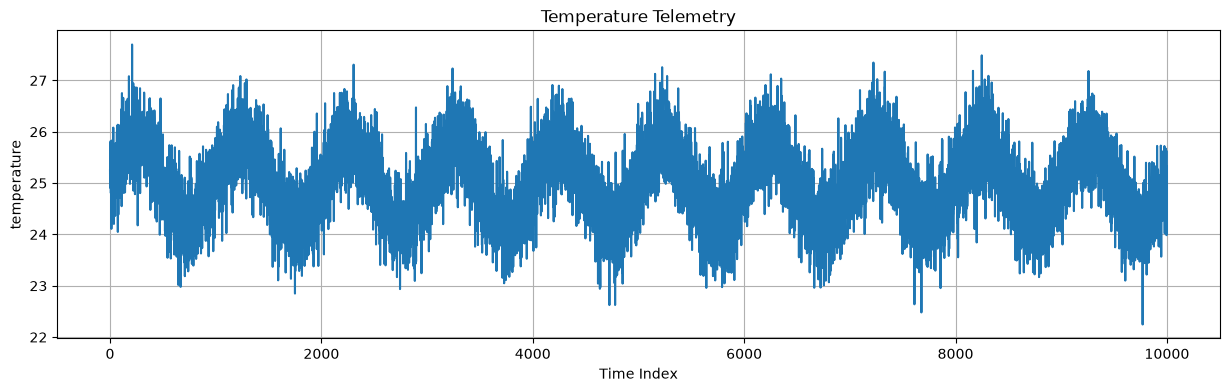

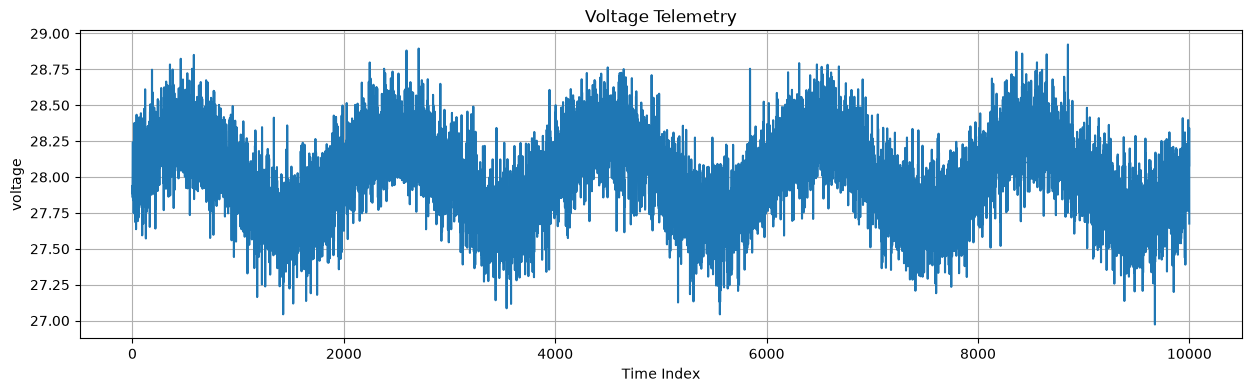

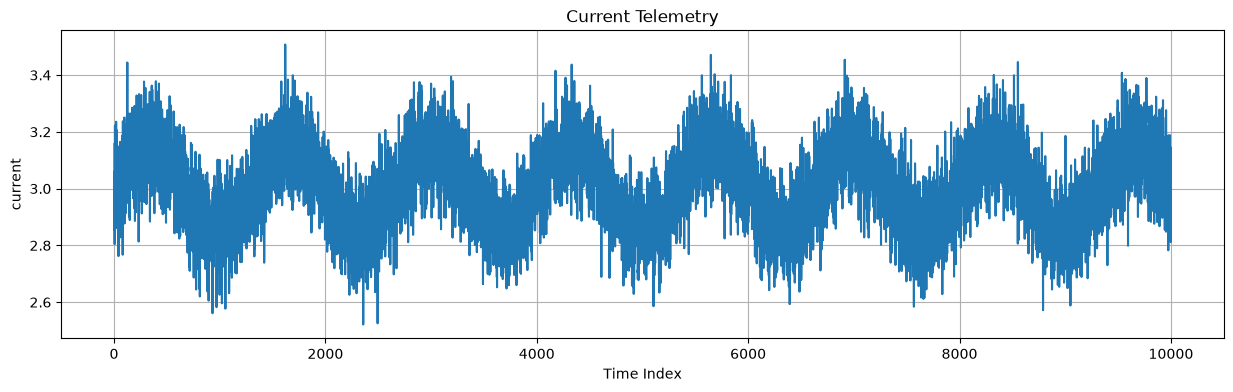

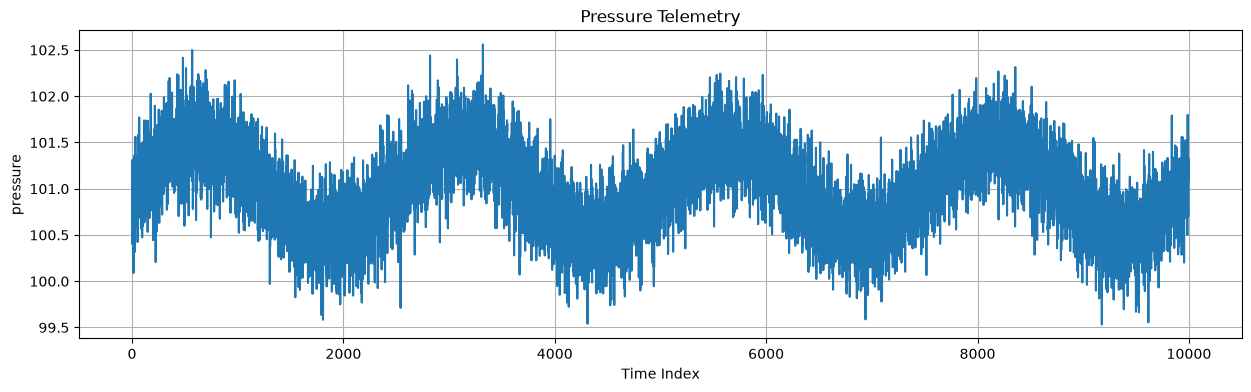

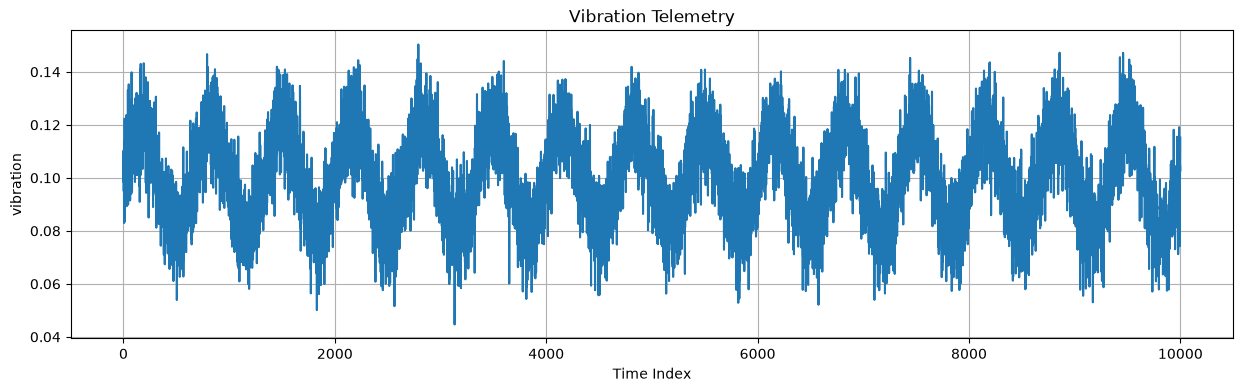

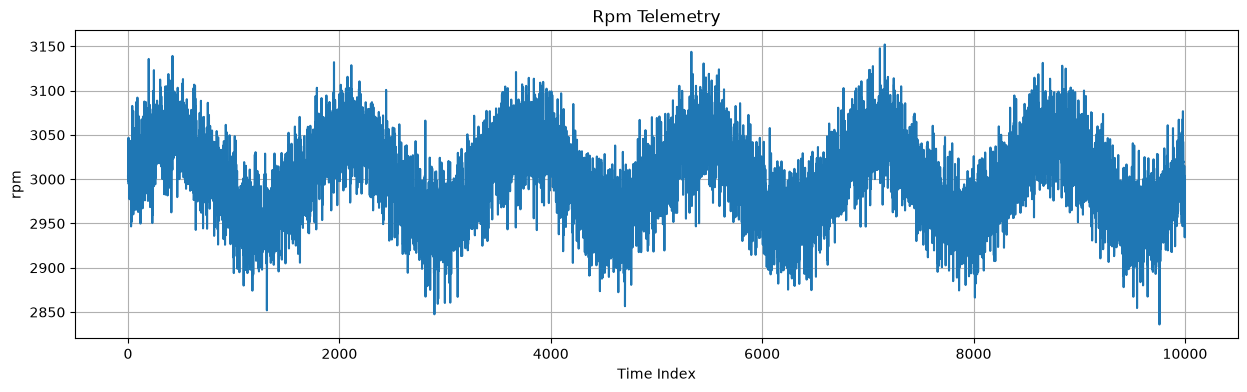

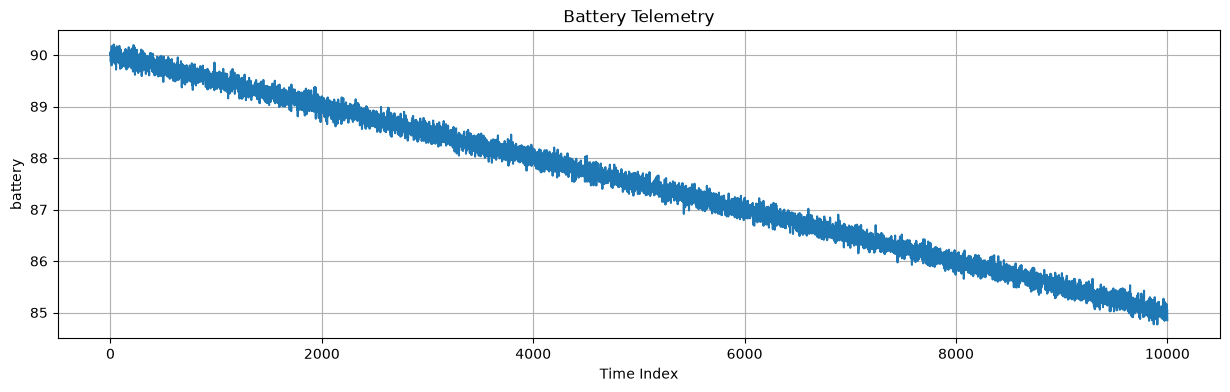

In [4]:
sensor_columns = [
    "temperature",
    "voltage",
    "current",
    "pressure",
    "vibration",
    "rpm",
    "battery"
]

for sensor in sensor_columns:

    plt.figure(figsize=(15, 4))

    plt.plot(df[sensor])

    plt.title(f"{sensor.capitalize()} Telemetry")
    plt.xlabel("Time Index")
    plt.ylabel(sensor)

    plt.grid(True)
    plt.show()

In [5]:
import pandas as pd

df_anomaly = pd.read_csv(
    "../data/synthetic/telemetry_with_anomalies.csv"
)

df_anomaly.head()

,timestamp,temperature,voltage,current,pressure,vibration,rpm,battery,anomaly,anomaly_type
0,2026-01-01 00:00:00,25.248357,27.864301,3.034829,100.405828,0.095281,3002.946184,90.007884,0,normal
1,2026-01-01 00:00:01,24.935895,27.939843,3.029039,100.684761,0.110316,2998.265267,90.055790,0,normal
2,2026-01-01 00:00:02,25.333898,27.882409,2.907762,100.826405,0.098395,3028.930748,90.033110,0,normal
3,2026-01-01 00:00:03,25.776595,28.024911,3.060079,101.048671,0.101471,3046.550465,89.870708,0,normal
4,2026-01-01 00:00:04,24.903029,28.243206,2.853819,101.312276,0.107928,3021.359437,89.979378,0,normal


In [6]:
print("Dataset shape:")
print(df_anomaly.shape)

print("\nColumns:")
print(df_anomaly.columns.tolist())

print("\nAnomaly count:")
print(df_anomaly["anomaly"].value_counts())

print("\nAnomaly types:")
print(df_anomaly["anomaly_type"].value_counts())

Dataset shape:
(10000, 10)

Columns:
['timestamp', 'temperature', 'voltage', 'current', 'pressure', 'vibration', 'rpm', 'battery', 'anomaly', 'anomaly_type']

Anomaly count:
anomaly
0    8943
1    1057
Name: count, dtype: int64

Anomaly types:
anomaly_type
normal                 8943
battery_degradation     301
sensor_drift            251
stuck_sensor            121
voltage_drop            101
high_vibration          101
correlated_failure      101
temperature_spike        81
Name: count, dtype: int64


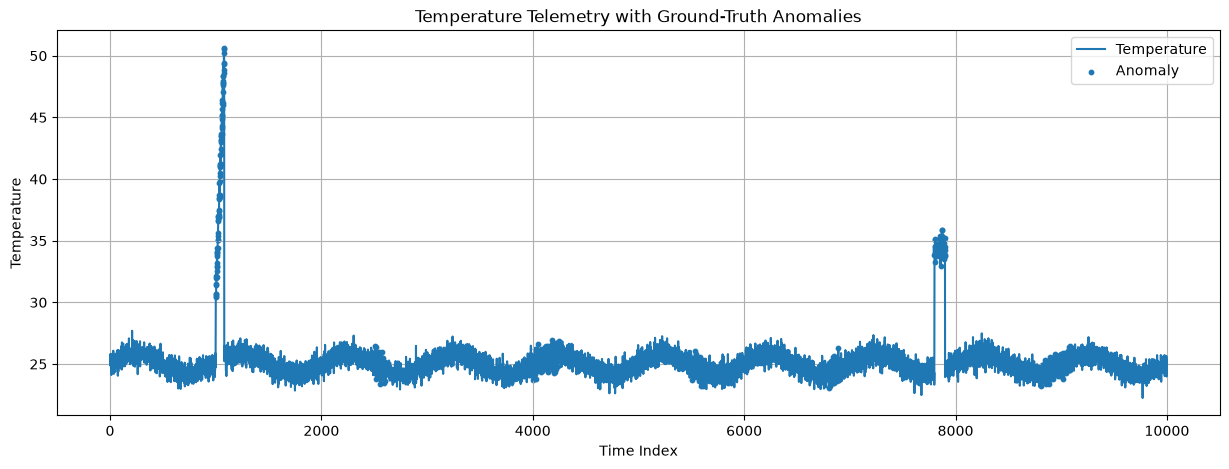

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(
    df_anomaly["temperature"],
    label="Temperature"
)

anomaly_points = df_anomaly[
    df_anomaly["anomaly"] == 1
]

plt.scatter(
    anomaly_points.index,
    anomaly_points["temperature"],
    s=10,
    label="Anomaly"
)

plt.title("Temperature Telemetry with Ground-Truth Anomalies")

plt.xlabel("Time Index")
plt.ylabel("Temperature")

plt.legend()
plt.grid(True)

plt.show()